*Use this notebook to complete the sentence similarity and embedding visualization tasks.*


In [1]:
import pickle
import numpy as np
from gensim.models import KeyedVectors

import nltk
from nltk.tokenize import word_tokenize
nltk.download("punkt")
nltk.download("punkt_tab")

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kenneth.cao/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kenneth.cao/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


*Loading all embeddings*

In [2]:
# 1) PyTorch-trained embeddings
with open("word2vec_embeddings.pkl", "rb") as f:
    pt = pickle.load(f)
pt_emb = pt["embeddings"]
pt_word2idx = pt["word2idx"]
pt_idx2word = pt["idx2word"]

# 2) Gensim-trained embeddings on text8
with open("word2vec_gensim_embeddings.pkl", "rb") as f:
    gs = pickle.load(f)
gs_emb = gs["embeddings"]      
gs_word2idx = gs["word2idx"]
gs_idx2word = gs["idx2word"]

# 3) Pretrained models

w2v_google = KeyedVectors.load("word2vec-google-news-300.model")
ft_wiki = KeyedVectors.load("fasttext-wiki-news-subwords-300.model")


*Sentence Similarity*

In [3]:
# List of sentences for comparison
sentences = [
    "The cat sat on the mat.",
    "A dog is playing in the yard.",
    "I need to buy groceries today.",
    "The feline was resting on the rug.",
    "Canines enjoy outdoor activities.",
    "My shopping list includes milk and bread.",
    "The weather is beautiful today.",
    "Programming requires logical thinking."
]

# Query sentence
query = "My pet cat is sleeping on the carpet."

def tokenize_text(text):
    return word_tokenize(text.lower())

q_toks = tokenize_text(query)

def cosine(a, b, eps=1e-9):
    return float(np.dot(a, b) / ((np.linalg.norm(a) * np.linalg.norm(b)) + eps))

def sent_vector_from_matrix(tokens, emb_matrix, word2idx):
    vecs = []
    for t in tokens:
        if t in word2idx:
            vecs.append(emb_matrix[word2idx[t]])
    if not vecs:
        return None
    return np.mean(np.vstack(vecs), axis=0)

def sent_vector_from_keyedvectors(tokens, kv):
    vecs = []
    for t in tokens:
        if t in kv.key_to_index:
            vecs.append(kv[t])
    if not vecs:
        return None
    return np.mean(np.vstack(vecs), axis=0)

def run_similarity(name, vec_fn):
    qv = vec_fn(q_toks)
    print(f"\n=== {name} ===")
    if qv is None:
        print("Query produced no vector (all OOV).")
        return
    for s in sentences:
        sv = vec_fn(tokenize_text(s))
        if sv is None:
            sim = None
        else:
            sim = cosine(qv, sv)
        print(f"{sim if sim is not None else 'N/A':>8}  |  {s}")

run_similarity("PyTorch (100d)", lambda toks: sent_vector_from_matrix(toks, pt_emb, pt_word2idx))
run_similarity("Gensim-trained (100d)", lambda toks: sent_vector_from_matrix(toks, gs_emb, gs_word2idx))
run_similarity("Pretrained Word2Vec GoogleNews (300d)", lambda toks: sent_vector_from_keyedvectors(toks, w2v_google))
run_similarity("Pretrained FastText WikiNews (300d)", lambda toks: sent_vector_from_keyedvectors(toks, ft_wiki))


=== PyTorch (100d) ===
0.5584630467891608  |  The cat sat on the mat.
0.49656942811133076  |  A dog is playing in the yard.
0.5020858905645071  |  I need to buy groceries today.
0.4947219856152189  |  The feline was resting on the rug.
0.07384516398762908  |  Canines enjoy outdoor activities.
0.45328141124469457  |  My shopping list includes milk and bread.
0.35080938732089545  |  The weather is beautiful today.
0.2394110746618089  |  Programming requires logical thinking.

=== Gensim-trained (100d) ===
0.7104094890354592  |  The cat sat on the mat.
0.5925923260862114  |  A dog is playing in the yard.
0.21543958177915112  |  I need to buy groceries today.
0.4843315982021812  |  The feline was resting on the rug.
0.0601411673710701  |  Canines enjoy outdoor activities.
0.4745156812914876  |  My shopping list includes milk and bread.
0.48228505011255884  |  The weather is beautiful today.
0.07621746756543012  |  Programming requires logical thinking.

=== Pretrained Word2Vec GoogleNews 

*Embedding Visualization*

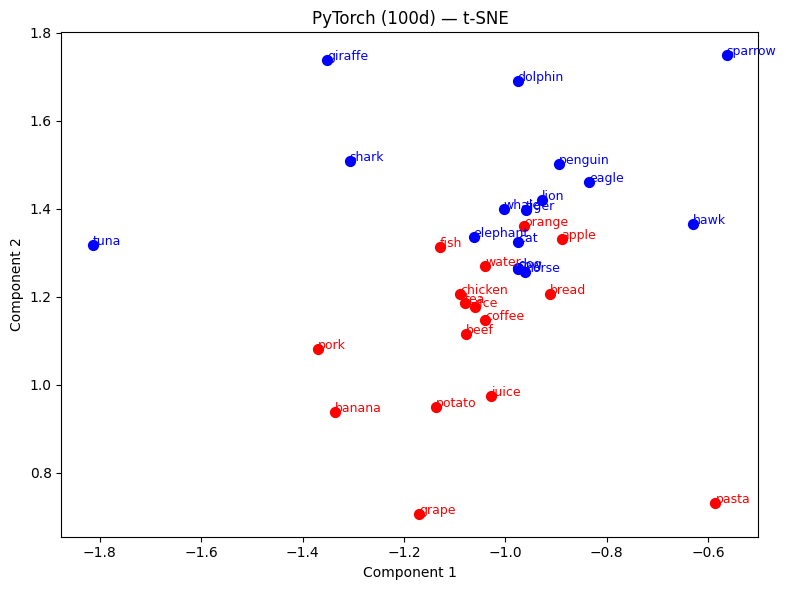

/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


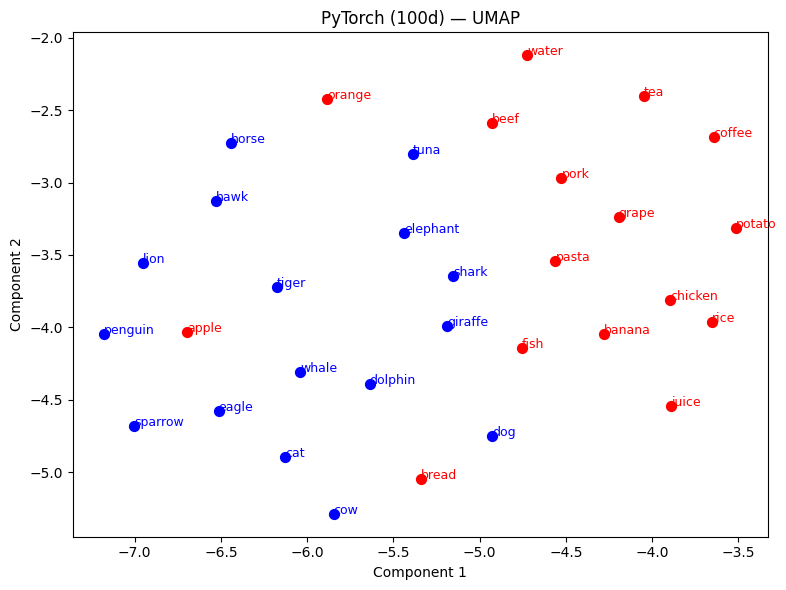

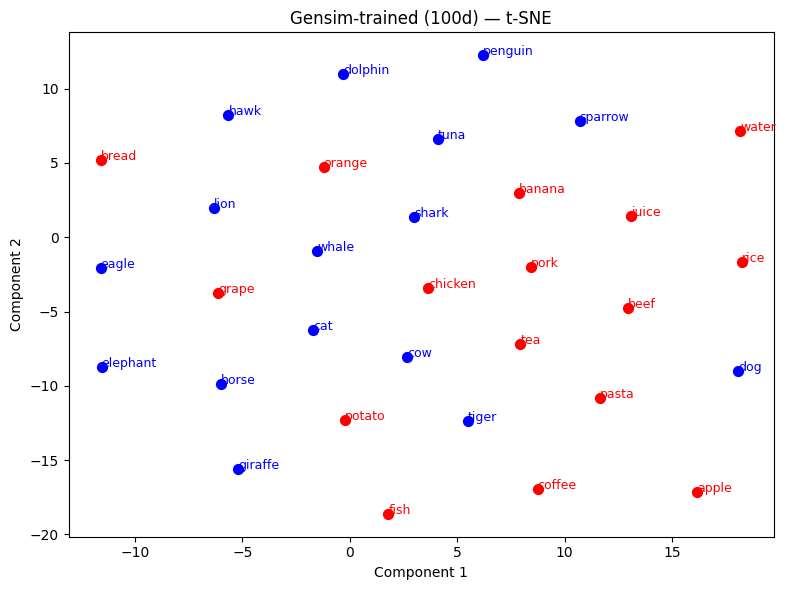

/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


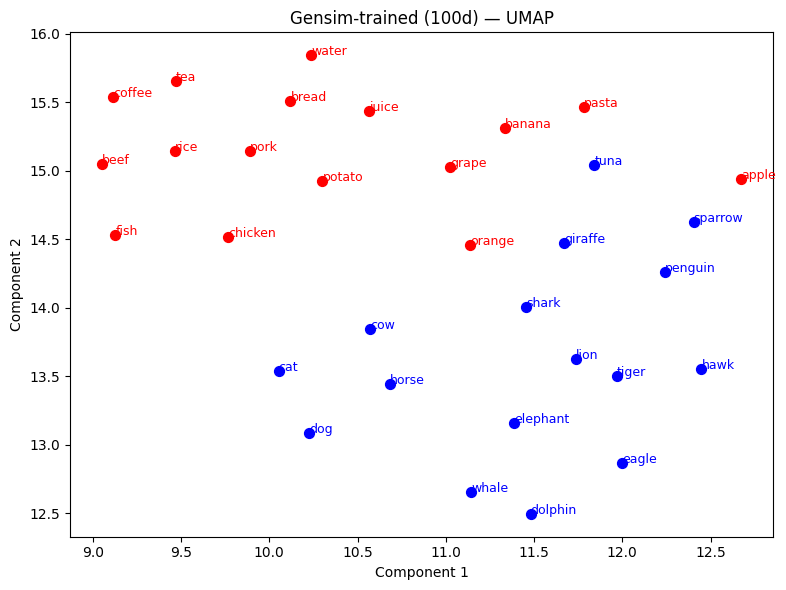

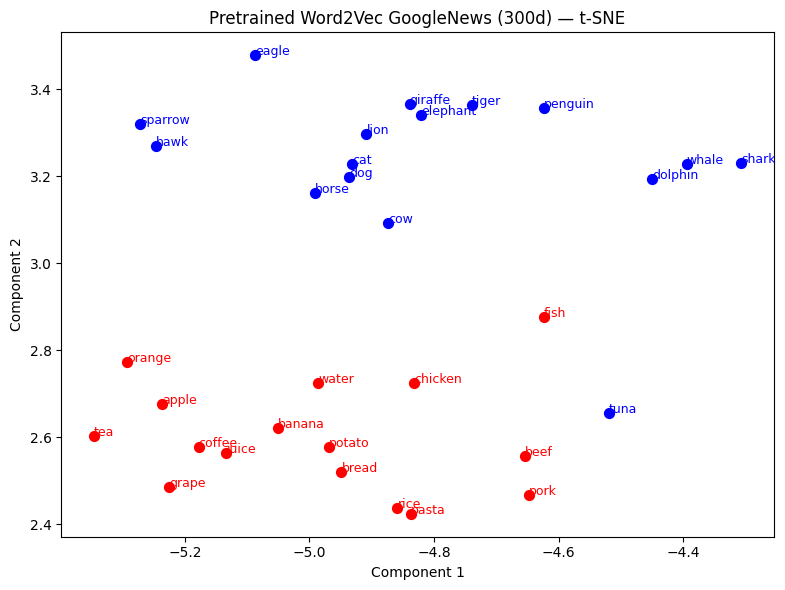

/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


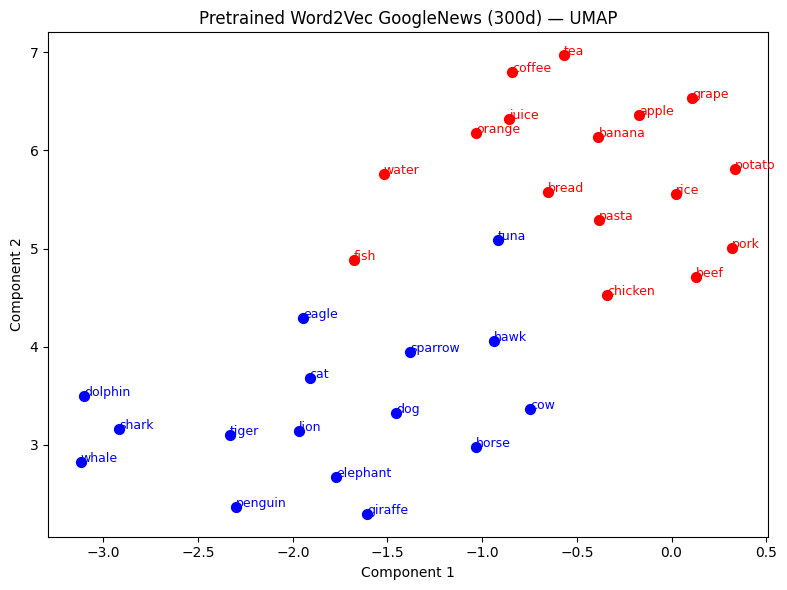

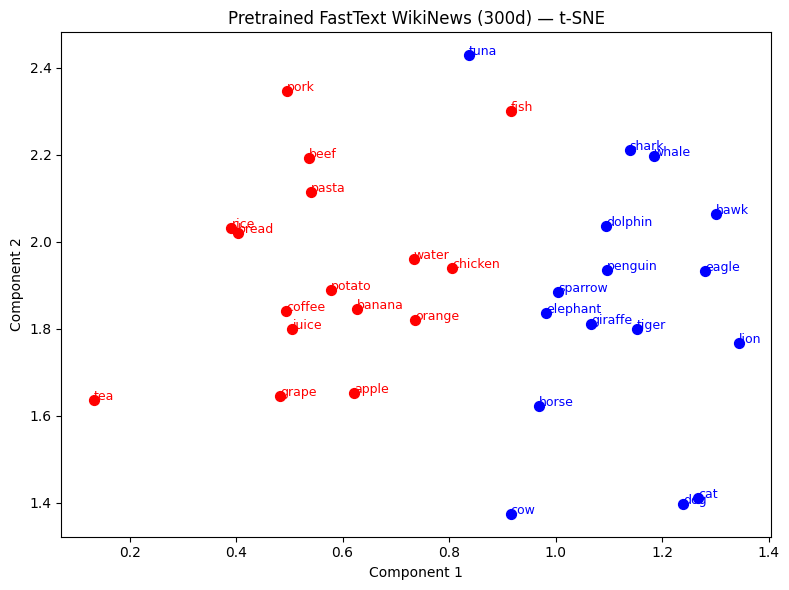

/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kenneth.cao/Desktop/Stat 359 (LLMs)/stat359/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


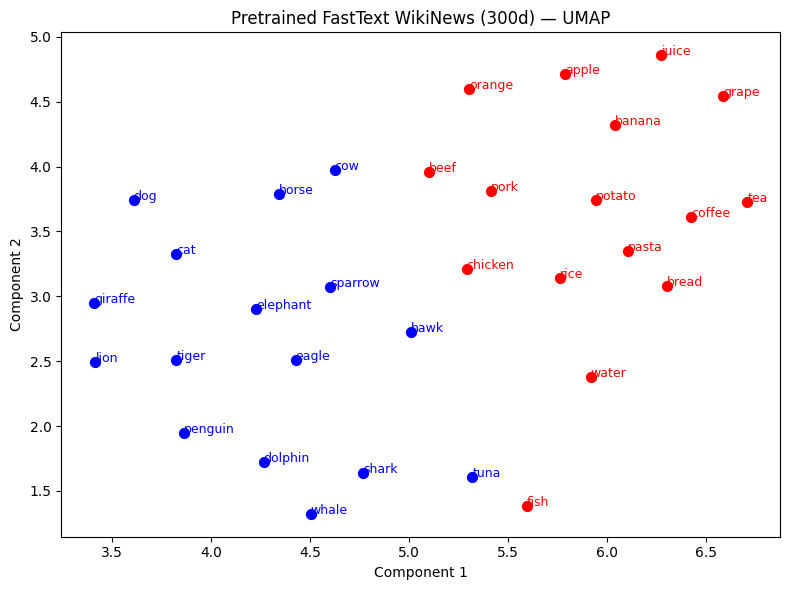

In [4]:
animals = [
    'dog', 'cat', 'horse', 'cow',
    'lion', 'tiger', 'elephant', 'giraffe',
    'eagle', 'hawk', 'sparrow', 'penguin',
    'shark', 'whale', 'dolphin', 'tuna'
]

foods = [
    'apple', 'orange', 'banana', 'grape',
    'bread', 'pasta', 'rice', 'potato',
    'chicken', 'beef', 'pork', 'fish',
    'coffee', 'tea', 'juice', 'water'
]

def get_vectors_for_words_matrix(words, emb_matrix, word2idx):
    kept_words, vecs = [], []
    for w in words:
        if w in word2idx:
            kept_words.append(w)
            vecs.append(emb_matrix[word2idx[w]])
    return kept_words, np.vstack(vecs) if vecs else None

def get_vectors_for_words_kv(words, kv):
    kept_words, vecs = [], []
    for w in words:
        if w in kv.key_to_index:
            kept_words.append(w)
            vecs.append(kv[w])
    return kept_words, np.vstack(vecs) if vecs else None

def plot_2d(points, words, n_animals, title):
    plt.figure(figsize=(8, 6))
    plt.title(title)
    
    # Plot animals in blue
    for i in range(n_animals):
        x, y = points[i]
        plt.scatter([x], [y], color='blue', s=50)
        plt.text(x, y, words[i], fontsize=9, color='blue')
    
    # Plot foods in red
    for i in range(n_animals, len(words)):
        x, y = points[i]
        plt.scatter([x], [y], color='red', s=50)
        plt.text(x, y, words[i], fontsize=9, color='red')
    
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.tight_layout()
    plt.show()

def visualize_source(source_name, get_vecs_fn):
    a_words, a_vecs = get_vecs_fn(animals)
    f_words, f_vecs = get_vecs_fn(foods)
    if a_vecs is None or f_vecs is None:
        print(f"{source_name}: Not enough words found to plot.")
        return

    X = np.vstack([a_vecs, f_vecs])
    words = a_words + f_words
    n_animals = len(a_words)

    # t-SNE
    tsne = TSNE(n_components=2, perplexity=min(30, len(words)-1), random_state=42)
    X_tsne = tsne.fit_transform(X)
    plot_2d(X_tsne, words, n_animals, f"{source_name} — t-SNE")

    # UMAP
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X)
    plot_2d(X_umap, words, n_animals, f"{source_name} — UMAP")

visualize_source("PyTorch (100d)", lambda ws: get_vectors_for_words_matrix(ws, pt_emb, pt_word2idx))
visualize_source("Gensim-trained (100d)", lambda ws: get_vectors_for_words_matrix(ws, gs_emb, gs_word2idx))
visualize_source("Pretrained Word2Vec GoogleNews (300d)", lambda ws: get_vectors_for_words_kv(ws, w2v_google))
visualize_source("Pretrained FastText WikiNews (300d)", lambda ws: get_vectors_for_words_kv(ws, ft_wiki))


*Short Answer Questions*

- For the embeddings, pretrained FastText WikiNews (300d) performed the best, with over a .9 score for the two sentences ("The cat sat on the mat" and "The feline was resting on the rug"). Though, it did overweigh the sentence: 'The weather is beautiful sentence' showing that FastText might end up smoothing representations too much.
- The pretrained embeddings performed much better as my model only had a score of around .5 for the two sentences we were targeting ("The cat sat on the mat" and "The feline was resting on the rug"), whereas the other models had at least a scores of .7 to .9 for the sentence: "The cat sat on the mat". Also when comparing the graphs, my embeddings (Pytorch t-SNE) still seem to have a large cluster of words around the middle compared to the other models. This could mean that the embedding space I trained is less structured and words are separated less than the pretrained ones.
- A factor that might explain the differences in performance is that they were trained on much more data. I used the data_full.py which only used the first 1701 sentences where the WikiNews and GoogleNews are presumably trained on billions of sentences. Also, the pretrained embeddings used 300 dimensions compared to 100 dimensions in my model, allowing those models to capture more semantic information. Another factor could be that the pretrained models are trained for much longer, I only ran 5 epochs whereas the pretrained embeddings might've ran for longer on much stronger computers.


*BONUS*

I want to test the pretrained embeddings on words with multiple senses (like we did in problem set 1), because it seems like the pretrained models did have a bit of trouble distinguishing "tuna" and "fish" between the food and animal groups as they can fit in both.

In [ ]:
def top_similar(model, word, topn=10):
    """Print top-n most similar words by cosine similarity."""
    try:
        sims = model.most_similar(word, topn=topn)
    except KeyError:
        print(f"'{word}' is not in the vocabulary.")
        return []

    print(f"Top {topn} most similar to '{word}':")
    for w, s in sims:
        print(f"  {w:20s} {s:.4f}")
    return sims


# Words with multiple senses
candidates = [
    "bank",    # money vs river
    "bat",     # animal vs object
    "head",    # body part vs leader
    "fish",    # animal vs food, comparison from above
    "tuna",    # food vs animal, comparison from above
]

print("GoogleNews")
for c in candidates:
    print("-" * 60)
    top_similar(w2v_google, c)

print("\nWikiNews")
for c in candidates:
    print("-" * 60)
    top_similar(ft_wiki, c)



GoogleNews
------------------------------------------------------------
Top 10 most similar to 'bank':
  banks                0.7441
  banking              0.6902
  Bank                 0.6699
  lender               0.6342
  banker               0.6093
  depositors           0.6032
  mortgage_lender      0.5798
  depositor            0.5716
  BofA                 0.5715
  Citibank             0.5590
------------------------------------------------------------
Top 10 most similar to 'bat':
  bats                 0.7678
  batting              0.6347
  Pinch_hitter_Brayan_Pena 0.6012
  batsman              0.5580
  batted               0.5542
  Hawaiian_hoary       0.5447
  Lelands.com_auctioned 0.5398
  yelled_Cheater       0.5380
  wicketkeeper_Andrew_Hodd 0.5371
  lefthanded_batter    0.5357
------------------------------------------------------------
Top 10 most similar to 'spring':
  summer               0.7651
  winter               0.6891
  autumn               0.6659
  springtime 

Similarly from assignment 1, even with better pretrained embeddings, the most frequent sense of a word dominates the learned embedding. This leads to other senses being diluted and sometimes removed from the top-10 most similar words. Interestingly, we see that 'tuna' for the WikiNews should much more similarity to foods compared to 'tuna' for GoogleNews which compares tuna similarly to species of tuna. This can explain the fact that 'tuna' is the only word that's on the left side with other foods in the t-SNE graph.

## AI Use Disclosure (Required)

If you used any AI-enabled tools (e.g., ChatGPT, GitHub Copilot, Claude, or other LLM assistants) while working on this assignment, you must disclose that use here. The goal is transparency-not punishment.

In your disclosure, briefly include:
- **Tool(s) used:** (name + version if known)
- **How you used them:** (e.g., concept explanation, debugging, drafting code, rewriting text)
- **What you verified yourself:** (e.g., reran the notebook, checked outputs/plots, checked shapes, read documentation)
- **What you did *not* use AI for (if applicable):** (optional)

You are responsible for the correctness of your submission, even if AI suggested code or explanations.

#### <font color="red">Write your disclosure here.</font>


I used ChatGPT model 5.2 and Claude Sonnet 4.5

- I mainly used ChatGPT for drafting my model and explaning concepts (the math and intuitions behind the models) by generating comments next to lines of code. 
- I used Claude to do some basic rechecking/debugging and optimization if I was confused by a concept. Then I would look at my notes to ensure that things were correct.
- I verified outputs through many reruns, rereading code, and also checking the output to ensure that it made sense.